<a href="https://colab.research.google.com/github/devparikh0506/learngrad/blob/main/notebooks/demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learngrad demo

In [1]:
!pip install --upgrade learngrad

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
from learngrad.engine import Value
from learngrad.nn import Neuron, Layer, MLP
from learngrad.optimizers import Adam

#### preparing dataset

In [6]:
from sklearn.datasets import make_circles

X, y = make_circles(1000, noise=0.1, factor=0.5)

y = y * 2 - 1

print(X.shape, y.shape)
print(X[:5])
print(y[:5])


(1000, 2) (1000,)
[[ 0.7820754  -0.70579846]
 [ 0.60510983 -0.13803417]
 [ 1.05012969 -0.06180626]
 [-0.56331271 -0.10097526]
 [ 0.14710088 -0.45817681]]
[-1  1 -1  1  1]


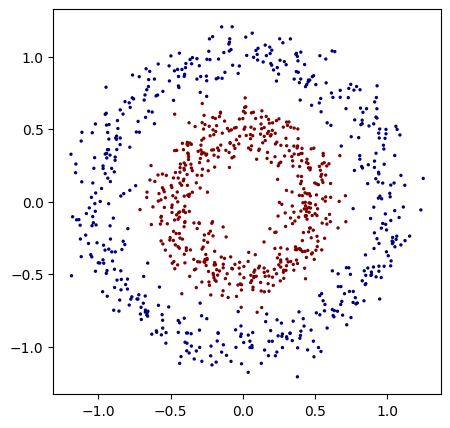

In [7]:
plt.figure(figsize=(5,5))
plt.scatter(X[:, 0], X[:, -1], c=y, s=2, cmap="jet")

In [8]:
def split_dataset(x, y, split_size = 0.8):
  split_idx = int(split_size * len(x))
  return x[:split_idx], y[:split_idx], x[split_idx:], y[split_idx:]

In [9]:
n_cols =X.shape[1]
X_train, y_train, X_val, y_val = split_dataset(X, y, 0.8)

In [10]:
def get_batches(X, y, batch_size):
    n = X.shape[0]
    ri = np.random.permutation(n)
    X_shuffled = X[ri]
    y_shuffled = y[ri]

    for i in range(0, n, batch_size):
        yield X_shuffled[i:i+batch_size], y_shuffled[i:i+batch_size]

In [11]:
class HingeLoss:
    def __call__(self, scores, ys):
        losses = [(1 + -yi * scorei).relu() for yi, scorei in zip(ys, scores)]
        self.loss = sum(losses) * (1.0 / len(losses))
        return self.loss

    def __repr__(self):
        return "HingeLoss()"

In [21]:

model = MLP(n_cols, [n_cols * 2, n_cols, 1])
print(model)
loss_fn = HingeLoss()
optimizer = Adam(model.parameters(), lr_decay=1e-4)


MLP(
Layer(4 x ReLUNeuron(2)),
Layer(2 x ReLUNeuron(4)),
Layer(LinearNeuron(2))
)


In [22]:
model(X[0])

Value(data=-0.7721827871764058, grad=0)

In [23]:
def train(model, X_train, y_train, optimizer, loss_fn, n_epochs=100,
          batch_size=None, alpha=1e-4, print_every=10, X_val=None, y_val=None):
    print(f"Training model: {model}")
    print("=" * 20)

    for i in range(n_epochs):
        epoch_losses = []
        if batch_size is None:
            batches = [(X_train, y_train)]
        else:
            batches = get_batches(X_train, y_train, batch_size=batch_size)

        n_batches = int(np.ceil(X_train.shape[0] / batch_size)) if batch_size else 1

        for Xb, yb in batches:
            inputs = [list(map(Value, xrow)) for xrow in Xb]
            scores = list(map(model, inputs))
            data_loss = loss_fn(scores, yb)

            # L2 regularization
            reg_loss = alpha * sum((p * p for p in model.parameters()))
            total_loss = data_loss + reg_loss
            epoch_losses.append(total_loss.data)

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()



        if i % print_every == 0:
            inputs_full = [list(map(Value, xrow)) for xrow in X_train]
            scores_full = list(map(model, inputs_full))
            train_acc = sum((yi > 0) == (si.data > 0)
                           for yi, si in zip(y_train, scores_full)) / len(y_train)

            # validation
            if X_val is not None and y_val is not None:
                inputs_val = [list(map(Value, xrow)) for xrow in X_val]
                scores_val = list(map(model, inputs_val))

                # val loss
                val_losses = [(1 + -yi * si).relu()
                             for yi, si in zip(y_val, scores_val)]
                val_loss = sum(val_losses) * (1.0 / len(val_losses))

                # val accuracy
                val_acc = sum((yi > 0) == (si.data > 0)
                             for yi, si in zip(y_val, scores_val)) / len(y_val)

                print(f"epoch: {i} | loss: {np.mean(epoch_losses):.4f} | acc: {train_acc*100:.1f}% | val_loss: {val_loss.data:.4f} | val_acc: {val_acc*100:.1f}%")
            else:
                print(f"epoch: {i} | loss: {np.mean(epoch_losses):.4f} | acc: {train_acc*100:.1f}%")

In [24]:
train(
    model=model,
    X_train=X_train,
    y_train=y_train,
    optimizer=optimizer,
    loss_fn=loss_fn,
    n_epochs=100,
    batch_size=32,
    alpha=1e-4,
    print_every=10,
    X_val=X_val,
    y_val=y_val
)

Training model: MLP(
Layer(4 x ReLUNeuron(2)),
Layer(2 x ReLUNeuron(4)),
Layer(LinearNeuron(2))
)
epoch: 0 | loss: 1.0145 | acc: 49.5% | val_loss: 0.9692 | val_acc: 52.0%
epoch: 10 | loss: 1.0087 | acc: 49.5% | val_loss: 0.9672 | val_acc: 52.0%
epoch: 20 | loss: 0.9880 | acc: 49.5% | val_loss: 0.9467 | val_acc: 52.0%
epoch: 30 | loss: 0.9609 | acc: 49.5% | val_loss: 0.9220 | val_acc: 52.0%
epoch: 40 | loss: 0.9051 | acc: 49.5% | val_loss: 0.8646 | val_acc: 52.0%
epoch: 50 | loss: 0.8168 | acc: 49.5% | val_loss: 0.7826 | val_acc: 52.0%
epoch: 60 | loss: 0.6908 | acc: 49.5% | val_loss: 0.6748 | val_acc: 52.0%
epoch: 70 | loss: 0.5790 | acc: 82.1% | val_loss: 0.5683 | val_acc: 81.0%
epoch: 80 | loss: 0.4738 | acc: 92.5% | val_loss: 0.4712 | val_acc: 93.0%
epoch: 90 | loss: 0.3722 | acc: 96.8% | val_loss: 0.3787 | val_acc: 96.5%


(-2.208833741716586, 2.041166258283414)

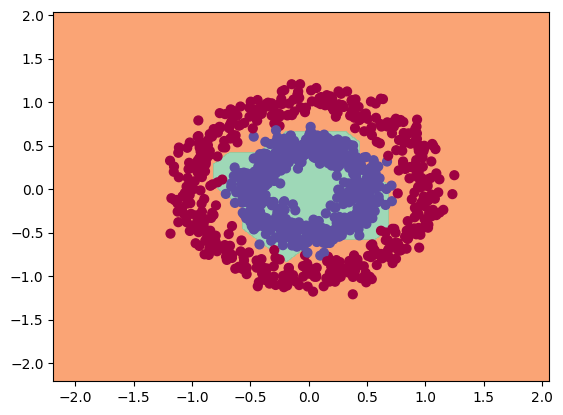

In [25]:

h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())